<a href="https://colab.research.google.com/github/paulallan2206/eda_house_price/blob/main/ML_Pipeline_%E2%80%94_Pakistan_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML Pipeline — Pakistan House Price Prediction**

Dataset  : Cleaned_data_for_model.csv (99 499 biens · 9 colonnes)
Modèles  : XGBoost · LightGBM
Métriques: RMSE · MAE · R² (sur prix réel après expm1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# 1.CHARGEMENT

In [2]:
df = pd.read_csv("/content/Cleaned_data_for_model.csv")
print(f"Shape brut : {df.shape}")


Shape brut : (99499, 9)


# 2.PREPROCESSING

Filtrer For Sale uniquement

In [3]:
df = df[df["purpose"] == "For Sale"].copy()
print(f"After For Sale filter : {len(df):,} biens")

After For Sale filter : 70,947 biens


Supprimer prix nuls

In [4]:
df = df[df["price"] > 0].copy()

 Clipper outliers au 99e percentile

In [5]:
p99 = df["price"].quantile(0.99)
df = df[df["price"] <= p99].copy()
print(f"After outlier removal  : {len(df):,} biens (p99 = {p99:,.0f} PKR)")

After outlier removal  : 70,475 biens (p99 = 42,500,000 PKR)


Filtrer types rares (< 200 biens) — Farm House, Room

In [6]:
type_counts = df["property_type"].value_counts()
valid_types = type_counts[type_counts >= 200].index
df = df[df["property_type"].isin(valid_types)].copy()
print(f"After type filter      : {len(df):,} biens")

After type filter      : 70,204 biens


Target : log1p(price)

In [7]:
df["log_price"] = np.log1p(df["price"])

print(f"\nDistribution log_price :")
print(df["log_price"].describe().round(3))


Distribution log_price :
count    70204.000
mean        16.228
std          0.755
min          9.680
25%         15.709
50%         16.300
75%         16.786
max         17.565
Name: log_price, dtype: float64


# 3. FEATURE ENGINEERING

In [8]:
def target_encode(df, col, target="log_price", min_samples=10):
    """Target Encoding avec smoothing pour éviter le data leakage."""
    global_mean = df[target].mean()
    stats = df.groupby(col)[target].agg(["mean", "count"])
    smoothing = 1 / (1 + np.exp(-(stats["count"] - min_samples) / min_samples))
    stats["encoded"] = smoothing * stats["mean"] + (1 - smoothing) * global_mean
    return df[col].map(stats["encoded"]).fillna(global_mean)


Target encoding : city + location

In [9]:
df["city_encoded"]     = target_encode(df, "city")
df["location_encoded"] = target_encode(df, "location")

Ratio baths / bedrooms (proxy standing)

In [13]:
df["bath_bed_ratio"] = df["baths"] / (df["bedrooms"] + 1)

# Prix par marla (feature de validation, exclue du training pour éviter leakage). On la garde pour analyse post-training

One-Hot Encoding : property_type

In [18]:
if "property_type" in df.columns:
    df = pd.get_dummies(df, columns=["property_type"], drop_first=True)
else:
    print("Warning: 'property_type' column not found, assuming one-hot encoding was already performed.")

print("\nFeatures créées :")
feature_cols = [
    "city_encoded", "location_encoded",
    "bedrooms", "baths", "Area_in_Marla",
    "bath_bed_ratio",
] + [c for c in df.columns if c.startswith("property_type_")]

print(feature_cols)


Features créées :
['city_encoded', 'location_encoded', 'bedrooms', 'baths', 'Area_in_Marla', 'bath_bed_ratio', 'property_type_House', 'property_type_Lower Portion', 'property_type_Upper Portion']


# 4. PRÉPARATION TRAIN / TEST

In [19]:
X = df[feature_cols].astype(float)
y = df["log_price"]
y_real = df["price"]  # Pour métriques sur prix réel

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")


X shape : (70204, 9)
y shape : (70204,)


# 5. CROSS-VALIDATION 5-FOLD — XGBoost

In [20]:
print("\n" + "="*55)
print("XGBoost — Cross Validation 5-Fold")
print("="*55)

xgb_params = {
    "n_estimators":      800,
    "max_depth":         6,
    "learning_rate":     0.05,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "min_child_weight":  3,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "random_state":      42,
    "n_jobs":            -1,
    "verbosity":         0,
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_rmse, xgb_mae, xgb_r2 = [], [], []
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    y_real_val     = y_real.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    preds_log  = model.predict(X_val)
    preds_real = np.expm1(preds_log)

    rmse = np.sqrt(mean_squared_error(y_real_val, preds_real))
    mae  = mean_absolute_error(y_real_val, preds_real)
    r2   = r2_score(y_real_val, preds_real)

    xgb_rmse.append(rmse)
    xgb_mae.append(mae)
    xgb_r2.append(r2)
    xgb_models.append(model)

    print(f"  Fold {fold} → RMSE: {rmse/1e6:.2f}M PKR | MAE: {mae/1e6:.2f}M PKR | R²: {r2:.4f}")

print(f"\n  Moyenne XGB → RMSE: {np.mean(xgb_rmse)/1e6:.2f}M ± {np.std(xgb_rmse)/1e6:.2f}M")
print(f"               MAE : {np.mean(xgb_mae)/1e6:.2f}M ± {np.std(xgb_mae)/1e6:.2f}M")
print(f"               R²  : {np.mean(xgb_r2):.4f} ± {np.std(xgb_r2):.4f}")


XGBoost — Cross Validation 5-Fold
  Fold 1 → RMSE: 3.62M PKR | MAE: 2.32M PKR | R²: 0.8619
  Fold 2 → RMSE: 3.60M PKR | MAE: 2.34M PKR | R²: 0.8639
  Fold 3 → RMSE: 3.66M PKR | MAE: 2.37M PKR | R²: 0.8600
  Fold 4 → RMSE: 3.68M PKR | MAE: 2.34M PKR | R²: 0.8557
  Fold 5 → RMSE: 3.62M PKR | MAE: 2.35M PKR | R²: 0.8585

  Moyenne XGB → RMSE: 3.63M ± 0.03M
               MAE : 2.35M ± 0.02M
               R²  : 0.8600 ± 0.0028


# 6. CROSS-VALIDATION 5-FOLD — LightGBM

In [21]:
print("\n" + "="*55)
print("LightGBM — Cross Validation 5-Fold")
print("="*55)

lgb_params = {
    "n_estimators":      800,
    "max_depth":         6,
    "learning_rate":     0.05,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "min_child_samples": 20,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "random_state":      42,
    "n_jobs":            -1,
    "verbosity":         -1,
}

lgb_rmse, lgb_mae, lgb_r2 = [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    y_real_val     = y_real.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

    preds_log  = model.predict(X_val)
    preds_real = np.expm1(preds_log)

    rmse = np.sqrt(mean_squared_error(y_real_val, preds_real))
    mae  = mean_absolute_error(y_real_val, preds_real)
    r2   = r2_score(y_real_val, preds_real)

    lgb_rmse.append(rmse)
    lgb_mae.append(mae)
    lgb_r2.append(r2)

    print(f"  Fold {fold} → RMSE: {rmse/1e6:.2f}M PKR | MAE: {mae/1e6:.2f}M PKR | R²: {r2:.4f}")

print(f"\n  Moyenne LGB → RMSE: {np.mean(lgb_rmse)/1e6:.2f}M ± {np.std(lgb_rmse)/1e6:.2f}M")
print(f"               MAE : {np.mean(lgb_mae)/1e6:.2f}M ± {np.std(lgb_mae)/1e6:.2f}M")
print(f"               R²  : {np.mean(lgb_r2):.4f} ± {np.std(lgb_r2):.4f}")




LightGBM — Cross Validation 5-Fold
  Fold 1 → RMSE: 3.65M PKR | MAE: 2.34M PKR | R²: 0.8590
  Fold 2 → RMSE: 3.60M PKR | MAE: 2.35M PKR | R²: 0.8635
  Fold 3 → RMSE: 3.66M PKR | MAE: 2.37M PKR | R²: 0.8601
  Fold 4 → RMSE: 3.70M PKR | MAE: 2.36M PKR | R²: 0.8545
  Fold 5 → RMSE: 3.62M PKR | MAE: 2.36M PKR | R²: 0.8583

  Moyenne LGB → RMSE: 3.65M ± 0.03M
               MAE : 2.36M ± 0.01M
               R²  : 0.8591 ± 0.0029


# 7. COMPARAISON VISUELLE XGB vs LGB

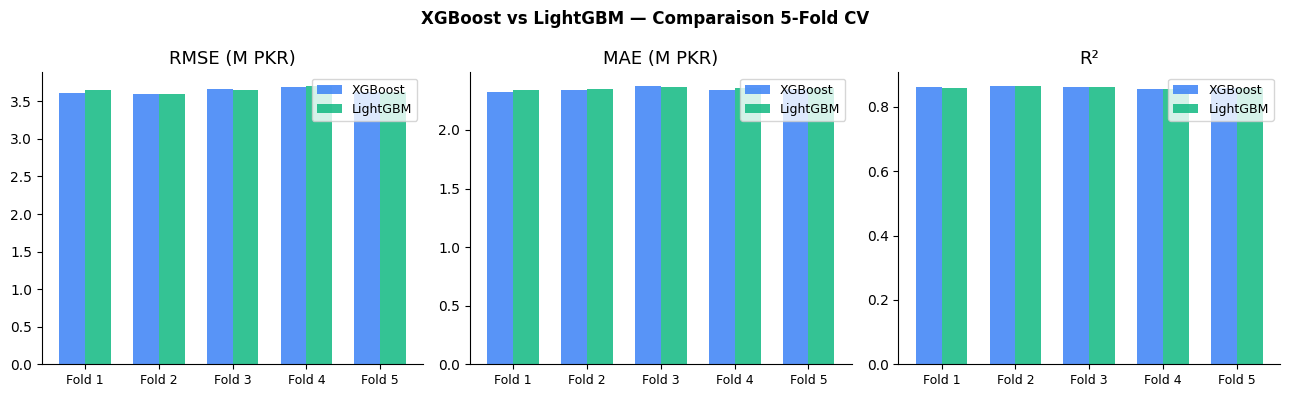

✓ 07_xgb_vs_lgb.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("XGBoost vs LightGBM — Comparaison 5-Fold CV", fontweight="bold")

metrics = {
    "RMSE (M PKR)": (
        [r/1e6 for r in xgb_rmse],
        [r/1e6 for r in lgb_rmse]
    ),
    "MAE (M PKR)": (
        [r/1e6 for r in xgb_mae],
        [r/1e6 for r in lgb_mae]
    ),
    "R²": (xgb_r2, lgb_r2),
}

for ax, (title, (xgb_vals, lgb_vals)) in zip(axes, metrics.items()):
    x = np.arange(5)
    w = 0.35
    ax.bar(x - w/2, xgb_vals, w, label="XGBoost", color="#3B82F6", alpha=0.85)
    ax.bar(x + w/2, lgb_vals,  w, label="LightGBM", color="#10B981", alpha=0.85)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {i+1}" for i in range(5)], fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("07_xgb_vs_lgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 07_xgb_vs_lgb.png")

# 8. FEATURE IMPORTANCE — meilleur modèle XGBoost (fold avec R² max)


Meilleur fold XGB : 2 (R² = 0.8639)


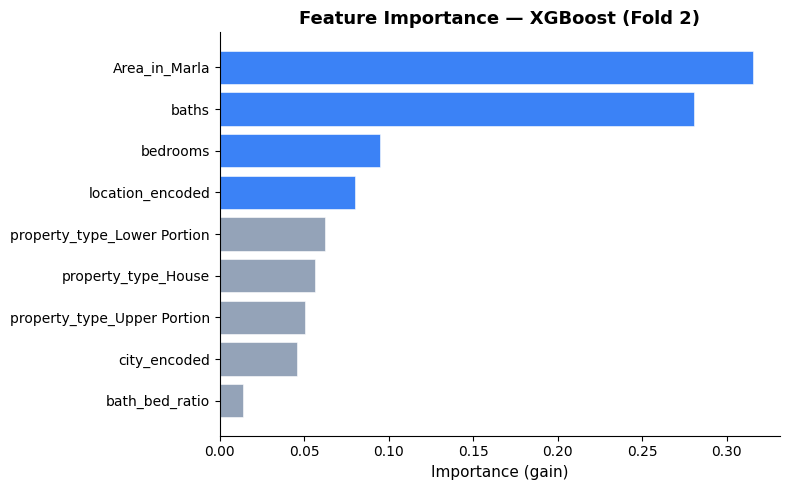

✓ 08_feature_importance.png


In [23]:
best_fold = int(np.argmax(xgb_r2))
best_model = xgb_models[best_fold]
print(f"\nMeilleur fold XGB : {best_fold + 1} (R² = {xgb_r2[best_fold]:.4f})")

importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#3B82F6" if v > importance.median() else "#94A3B8"
          for v in importance.values]
ax.barh(importance.index, importance.values, color=colors, edgecolor="white", linewidth=0.4)
ax.set_title(f"Feature Importance — XGBoost (Fold {best_fold+1})", fontweight="bold")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 08_feature_importance.png")


# 9. SHAP VALUES


Calcul SHAP values...


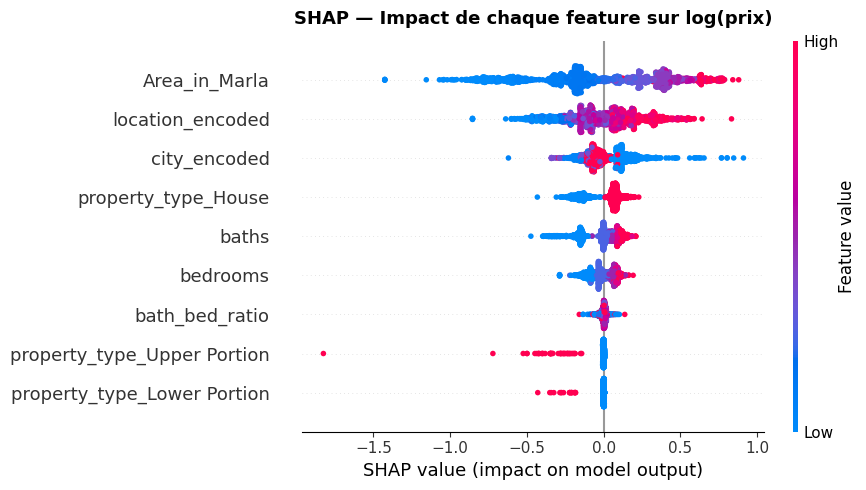

✓ 09_shap_summary.png


In [24]:
try:
    import shap
    print("\nCalcul SHAP values...")

    # Sample 2000 pour la vitesse
    train_idx_best = list(kf.split(X))[best_fold][0]
    val_idx_best   = list(kf.split(X))[best_fold][1]
    X_val_best     = X.iloc[val_idx_best]
    sample_idx     = np.random.choice(len(X_val_best), size=min(2000, len(X_val_best)), replace=False)
    X_sample       = X_val_best.iloc[sample_idx]

    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sample)

    # Beeswarm plot
    fig, ax = plt.subplots(figsize=(9, 5))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                      show=False, plot_size=None)
    plt.title("SHAP — Impact de chaque feature sur log(prix)", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig("09_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ 09_shap_summary.png")

except ImportError:
    print("⚠ SHAP non installé → pip install shap")

# 10. ANALYSE DES ERREURS PAR VILLE


=== Erreur par ville (fold validation) ===
            mean_error  median_abs_error
city                                    
Faisalabad        4.58             16.43
Islamabad        13.70             13.11
Karachi          17.32             15.72
Lahore           18.41             11.18
Rawalpindi        3.28             11.83


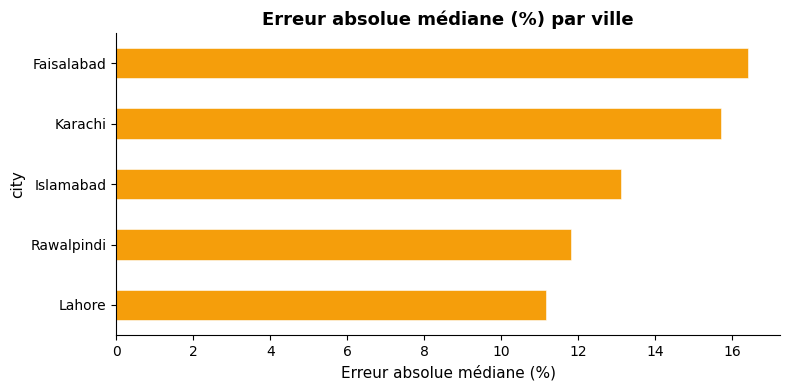

✓ 10_error_by_city.png


In [25]:
val_df = df.iloc[val_idx_best].copy()
val_df["pred_log"]  = best_model.predict(X.iloc[val_idx_best])
val_df["pred_real"] = np.expm1(val_df["pred_log"])
val_df["error_pct"] = ((val_df["pred_real"] - val_df["price"]) / val_df["price"]) * 100

city_errors = val_df.groupby("city")["error_pct"].agg(
    mean_error="mean",
    median_abs_error=lambda x: x.abs().median()
).round(2)

print("\n=== Erreur par ville (fold validation) ===")
print(city_errors)

fig, ax = plt.subplots(figsize=(8, 4))
city_errors["median_abs_error"].sort_values().plot.barh(
    ax=ax, color="#F59E0B", edgecolor="white", linewidth=0.4
)
ax.set_title("Erreur absolue médiane (%) par ville", fontweight="bold")
ax.set_xlabel("Erreur absolue médiane (%)")
plt.tight_layout()
plt.savefig("10_error_by_city.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 10_error_by_city.png")

# 11. RÉSUMÉ FINAL

In [28]:
print("\n" + "="*55)
print("RÉSUMÉ FINAL")
print("="*55)
print(f"  Biens entraînement     : {len(df):,}")
print(f"  Features               : {len(feature_cols)}")
print()
print(f"  XGBoost  → R²: {np.mean(xgb_r2):.4f} | RMSE: {np.mean(xgb_rmse)/1e6:.2f}M PKR")
print(f"  LightGBM → R²: {np.mean(lgb_r2):.4f} | RMSE: {np.mean(lgb_rmse)/1e6:.2f}M PKR")
print()
winner = "XGBoost" if np.mean(xgb_r2) > np.mean(lgb_r2) else "LightGBM"
print(f"  ✓ Meilleur modèle : {winner}")


RÉSUMÉ FINAL
  Biens entraînement     : 70,204
  Features               : 9

  XGBoost  → R²: 0.8600 | RMSE: 3.63M PKR
  LightGBM → R²: 0.8591 | RMSE: 3.65M PKR

  ✓ Meilleur modèle : XGBoost
